# 01. EDA & 가설 검증 (BMI_group 5구간, 상관관계·가설1~3, 히트맵)

원본 통합노트북 셀 0~40. PPT의 데이터정리/상관관계/가설1,2,3/BMI그룹 히트맵 슬라이드와 대응됩니다. 자세한 매핑은 `docs/02_analysis_pipeline.md` 참고.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from math import pi

In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 32.7 MB/s eta 0:00:00


In [ ]:
C_SMOKER = '#A63A50'
C_HIGH_BMI = '#C65D6E'
C_NONSMOKER = '#6B7075'
C_LOW_BMI = '#2F3437'
C_TEXT = '#1E1E1E'
C_GRID = '#D9D9D9'

sns.set_palette([C_NONSMOKER, C_SMOKER])
plt.rcParams.update({
    "text.color": C_TEXT,
    "axes.labelcolor": C_TEXT,
    "xtick.color": C_TEXT,
    "ytick.color": C_TEXT
})

In [ ]:
df = pd.read_csv('/content/train_dataset.csv')

In [ ]:
df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0


In [ ]:
df.info() # 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  38984 non-null  int64  
 1   height(cm)           38984 non-null  int64  
 2   weight(kg)           38984 non-null  int64  
 3   waist(cm)            38984 non-null  float64
 4   eyesight(left)       38984 non-null  float64
 5   eyesight(right)      38984 non-null  float64
 6   hearing(left)        38984 non-null  int64  
 7   hearing(right)       38984 non-null  int64  
 8   systolic             38984 non-null  int64  
 9   relaxation           38984 non-null  int64  
 10  fasting blood sugar  38984 non-null  int64  
 11  Cholesterol          38984 non-null  int64  
 12  triglyceride         38984 non-null  int64  
 13  HDL                  38984 non-null  int64  
 14  LDL                  38984 non-null  int64  
 15  hemoglobin           38984 non-null 

In [ ]:
df.duplicated().sum()
train = df.drop_duplicates()
train.duplicated().sum()

np.int64(0)

In [ ]:
train.describe() #시력 9.9, ALT 2914등 이상치 값이 많다는 사실을 알 수 있다.

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,...,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000
mean,44.153943,164.684465,65.930319,82.081501,1.013849,1.009553,1.025368,1.026056,121.498730,76.017599,...,57.257537,115.182090,14.624463,1.086533,0.886467,26.195536,27.139929,39.952401,0.214689,0.366271
std,12.071768,9.195867,12.877955,9.310533,0.496245,0.497867,0.157243,0.159303,13.671019,9.672070,...,14.598021,43.159159,1.562414,0.403008,0.222038,18.760580,31.613159,49.965736,0.410613,0.481792
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,2.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,66.000000,136.000000,15.700000,1.000000,1.000000,29.000000,31.000000,44.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,233.000000,146.000000,...,359.000000,1860.000000,21.100000,6.000000,11.600000,1090.000000,2914.000000,999.000000,1.000000,1.000000


In [ ]:
train = df[
    (df['Gtp'] < 500) &
    (df['ALT'] < 500) &
    (df['AST'] < 500) &
    (df['LDL'] < 400) &
    (df['serum creatinine'] < 3.0) &
    (df['eyesight(left)'] <= 3.0) &
    (df['eyesight(right)'] <= 3.0)
].copy()
train.describe()
# 이상치 제거 완료

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,...,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000
mean,44.077568,164.695534,65.941533,82.047630,0.999411,0.993645,1.025013,1.025761,121.442204,75.980305,...,57.292488,114.556427,14.623696,1.085003,0.884228,25.877956,26.692669,38.710712,0.214584,0.366882
std,12.041763,9.191880,12.895172,9.325185,0.326393,0.325241,0.156166,0.158425,13.632417,9.658122,...,14.616465,33.557568,1.566662,0.396592,0.191950,13.597727,20.422636,41.335390,0.410539,0.481960
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,3.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,2.000000,2.000000,2.000000,2.000000,233.000000,146.000000,...,359.000000,379.000000,21.100000,6.000000,2.600000,387.000000,471.000000,497.000000,1.000000,1.000000


In [ ]:
train['BMI'] = train['weight(kg)']/(train['height(cm)']/100)**2
train['BMI_group'] =pd.cut(train['BMI'],
                                 bins=[0, 18.5, 23, 25, 30, 100],
                                 labels=['저체중', '정상', '과체중', '비만2단계', '고도비만'])
train['BMI_group']
#BMI 분류하기

,BMI_group
0,비만2단계
1,고도비만
3,비만2단계
4,정상
5,정상
...,...
38979,정상
38980,정상
38981,고도비만
38982,정상


In [ ]:
train

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,BMI_group
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,19.8,1,1.0,61,115,125,1,1,29.411765,비만2단계
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,15.9,1,1.1,19,25,30,1,0,35.918367,고도비만
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,16.9,1,0.9,32,36,36,0,0,29.384757,비만2단계
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,14.9,1,1.2,26,28,15,0,0,22.038567,정상
5,60,160,50,78.0,1.0,0.9,2,2,126,75,...,13.9,1,1.0,47,23,70,0,1,19.531250,정상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38979,40,165,60,80.0,0.4,0.6,1,1,107,60,...,12.3,1,0.5,18,18,21,1,0,22.038567,정상
38980,45,155,55,75.0,1.5,1.2,1,1,126,72,...,12.5,2,0.6,23,11,12,0,0,22.892820,정상
38981,40,170,105,124.0,0.6,0.5,1,1,141,85,...,17.1,1,0.8,24,23,35,1,1,36.332180,고도비만
38982,40,160,55,75.0,1.5,1.5,1,1,95,69,...,12.0,1,0.6,24,20,17,0,1,21.484375,정상


In [ ]:
train.isnull().sum()

,0
age,0
height(cm),0
weight(kg),0
waist(cm),0
eyesight(left),0
eyesight(right),0
hearing(left),0
hearing(right),0
systolic,0
relaxation,0


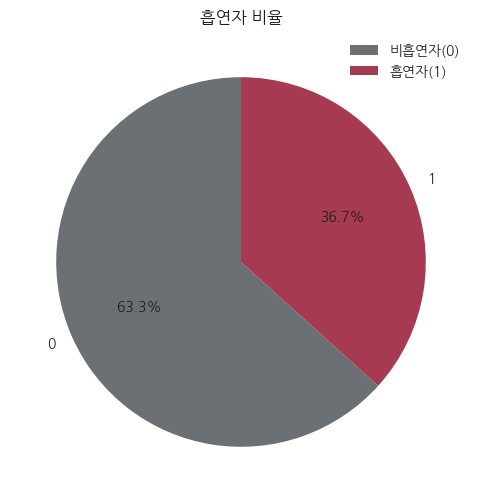

In [ ]:
train['smoking']
ts = train['smoking'].value_counts()
#흡연 비흡연 인원 수
ts.plot(kind="pie",autopct='%1.1f%%', figsize=(6,6), startangle=90,
        colors=[C_NONSMOKER, C_SMOKER])
plt.legend(['비흡연자(0)', '흡연자(1)'], loc="upper right", frameon=False)
plt.title("흡연자 비율")
plt.ylabel("")  # 불필요한 y라벨 제거
plt.show()

In [ ]:
corr = train.corr(numeric_only=True)
corr
corr = train.select_dtypes(include='number').corr()['smoking'].drop('smoking').sort_values(ascending=True)
corr
# 흡연 여부 상관계수 파악하기

,smoking
HDL,-0.180899
age,-0.167949
LDL,-0.053937
Cholesterol,-0.027135
hearing(left),-0.022810
hearing(right),-0.020335
Urine protein,0.014296
systolic,0.070547
AST,0.082912
eyesight(left),0.097287


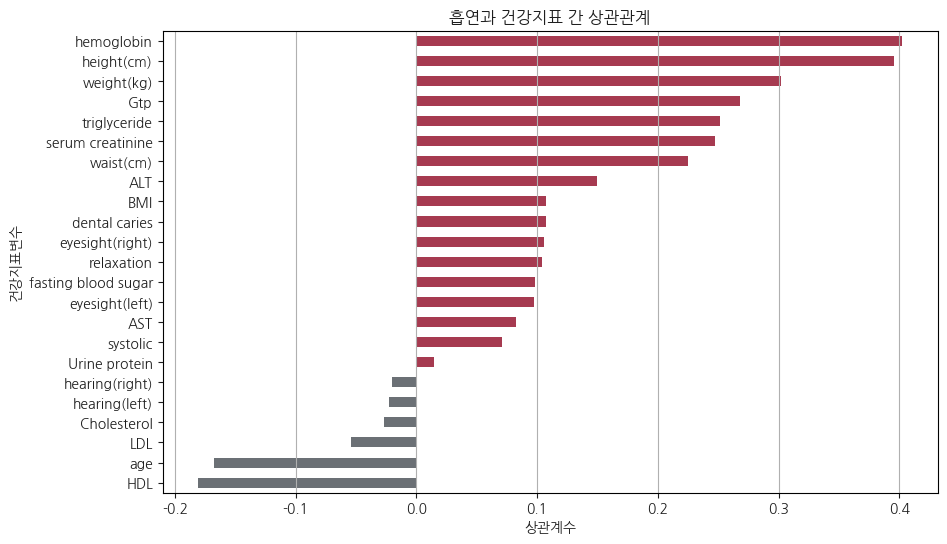

In [ ]:
colors = [C_SMOKER if x >= 0 else C_NONSMOKER for x in corr.values]
corr.plot(kind="barh",color=colors, figsize=(10,6))
plt.title('흡연과 건강지표 간 상관관계', color=C_TEXT)
plt.xlabel('상관계수', color=C_TEXT)
plt.ylabel('건강지표변수', color=C_TEXT)
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

In [ ]:
#BMI로 구간을 나누어서 헤모글로빈과 흡연 유무 차이 파악해보기

group=train.groupby(['BMI_group', 'smoking'])
grouped =group['hemoglobin'].mean().unstack()
grouped

/tmp/ipykernel_10859/1629066339.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group=train.groupby(['BMI_group', 'smoking'])


smoking,0,1
BMI_group,,
저체중,13.327962,14.888295
정상,13.786290,15.183462
과체중,14.269006,15.472650
비만2단계,14.600883,15.645674
고도비만,14.683651,15.905907


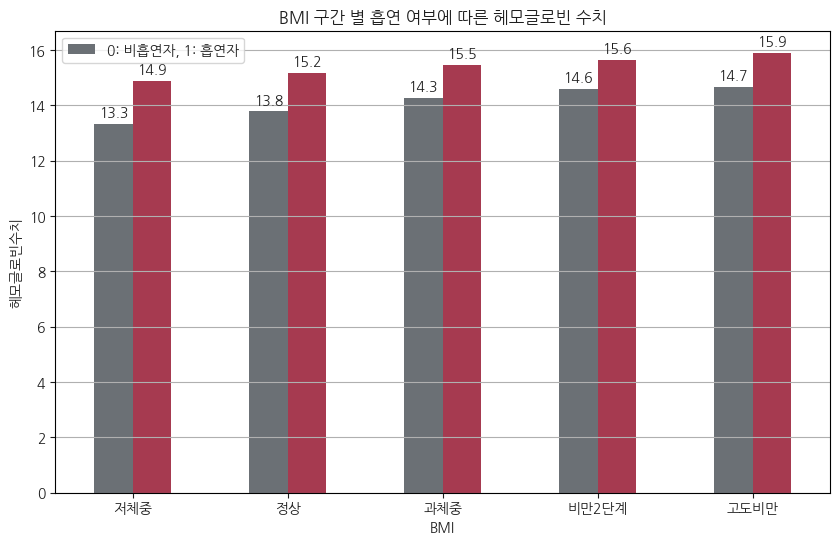

In [ ]:
grouped.plot(kind="bar", figsize=(10,6))

plt.title('BMI 구간 별 흡연 여부에 따른 헤모글로빈 수치')
plt.xlabel('BMI')
plt.ylabel('헤모글로빈수치')
plt.xticks(rotation=0)
plt.legend(['0: 비흡연자, 1: 흡연자'])
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3)
plt.grid(axis='y')
plt.show()

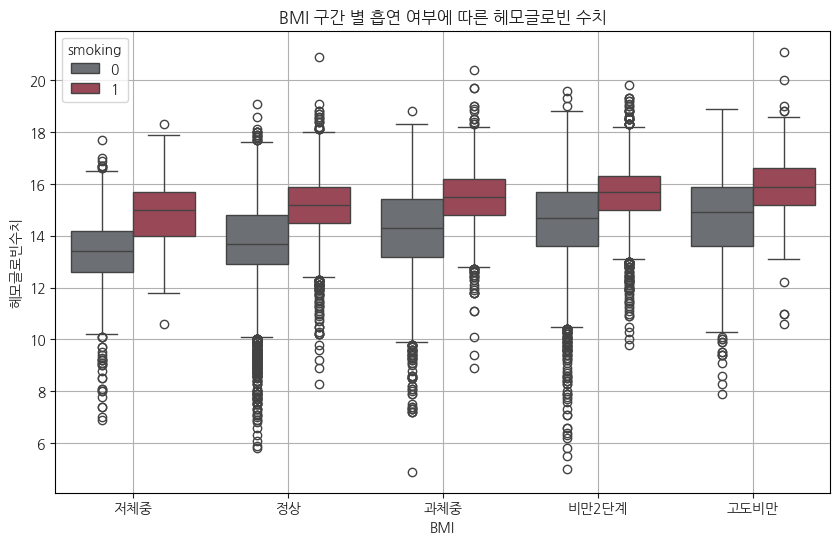

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='BMI_group',y='hemoglobin', hue='smoking', data=train)

plt.title('BMI 구간 별 흡연 여부에 따른 헤모글로빈 수치')
plt.xlabel('BMI')
plt.ylabel('헤모글로빈수치')
plt.grid(True)

plt.show()

In [ ]:
bins =[20, 30, 40, 50, 60, 70, 100]
labels=['20대', '30대', '40대', '50대', '60대', '70대+']
train['age_group']=pd.cut(train['age'], bins=bins, labels=labels, right=False)
#나이 그룹 만들기

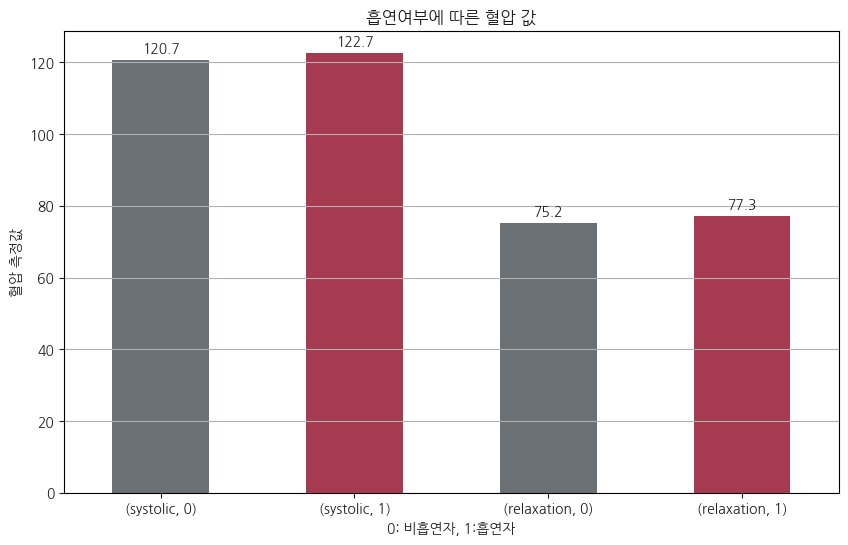

In [ ]:
blood_pressure = train.groupby('smoking')[['systolic', 'relaxation']].mean().unstack()
blood_pressure
blood_pressure.plot(kind="bar",color=[C_NONSMOKER, C_SMOKER], figsize=(10,6),)

plt.title('흡연여부에 따른 혈압 값')
plt.xlabel('0: 비흡연자, 1:흡연자')
plt.ylabel('혈압 측정값')
plt.xticks(rotation=0)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3)
plt.grid(axis='y')
plt.show()

/tmp/ipykernel_10859/1263443086.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sys = train.groupby(['age_group','smoking' ])[['systolic']].mean().unstack()


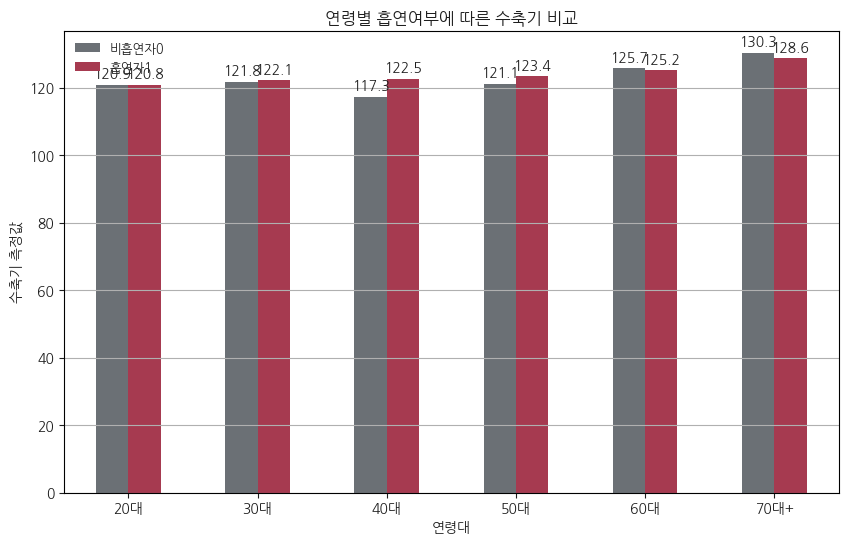

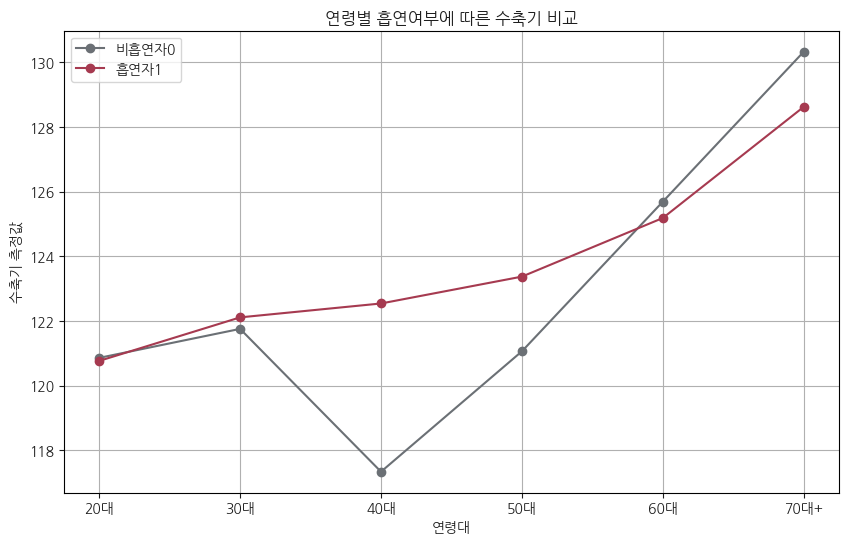

In [ ]:
#연령별 흡연여부에 따른 수축기 비교
age_sys = train.groupby(['age_group','smoking' ])[['systolic']].mean().unstack()
age_sys
age_sys.plot(kind="bar", figsize=(10,6))
plt.title('연령별 흡연여부에 따른 수축기 비교')
plt.xlabel('연령대')
plt.ylabel('수축기 측정값')
plt.legend(['비흡연자0', '흡연자1'], fontsize=9, frameon=False)
plt.xticks(rotation=0)
plt.grid(axis='y')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3)
plt.show()


age_sys.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("연령별 흡연여부에 따른 수축기 비교")
plt.xlabel("연령대")
plt.ylabel("수축기 측정값")
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(True)
plt.show()

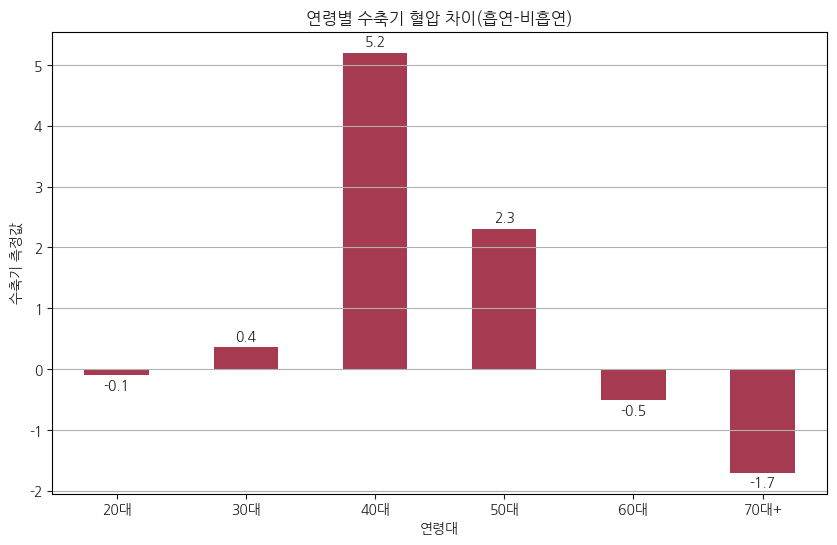

In [ ]:
a= age_sys['systolic'][1]-age_sys['systolic'][0]
a.plot(kind="bar", figsize=(10,6),
       color=C_SMOKER)
plt.title('연령별 수축기 혈압 차이(흡연-비흡연)')
plt.xlabel('연령대')
plt.ylabel('수축기 측정값')
plt.xticks(rotation=0)
plt.grid(axis='y')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3)
plt.show()

/tmp/ipykernel_10859/899100092.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_relax = train.groupby(['age_group','smoking' ])[['relaxation']].mean().unstack()


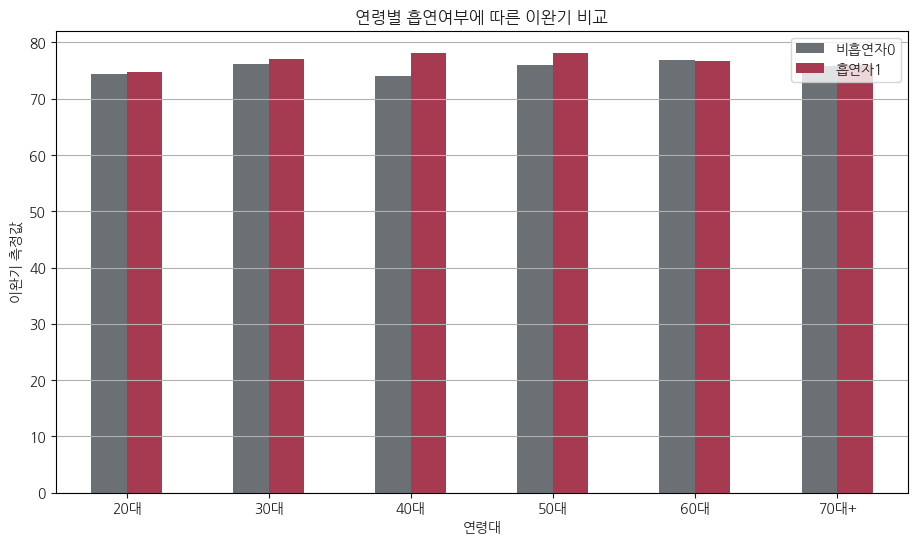

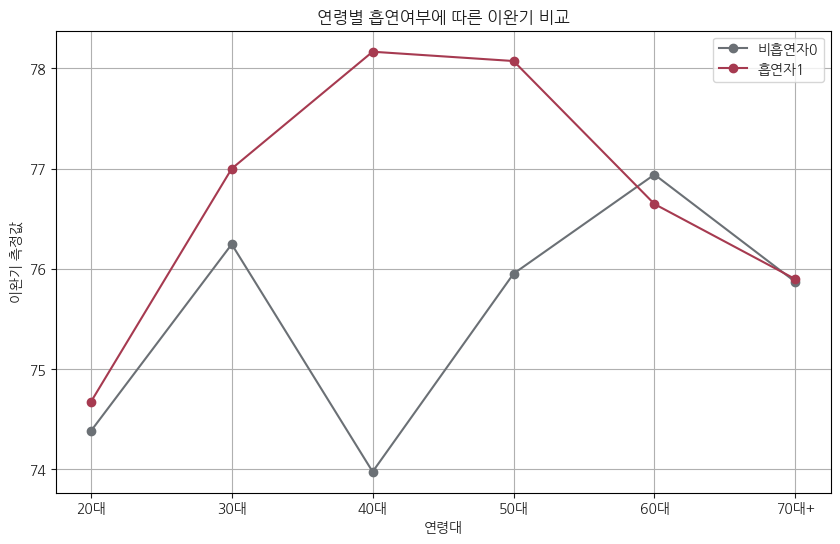

In [ ]:
#연령별 흡연여부에 따른 이완기 비교
age_relax = train.groupby(['age_group','smoking' ])[['relaxation']].mean().unstack()
age_relax
age_relax.plot(kind="bar", figsize=(11,6))
plt.title('연령별 흡연여부에 따른 이완기 비교')
plt.xlabel('연령대')
plt.ylabel('이완기 측정값')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

age_relax.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("연령별 흡연여부에 따른 이완기 비교")
plt.xlabel("연령대")
plt.ylabel("이완기 측정값")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

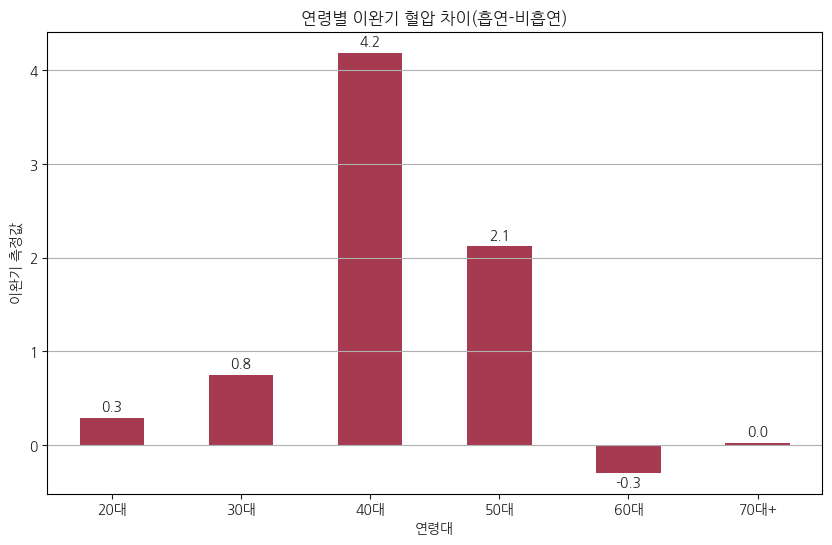

In [ ]:
r= age_relax['relaxation'][1]-age_relax['relaxation'][0]
r.plot(kind="bar", figsize=(10,6),
       color=C_SMOKER)
plt.title('연령별 이완기 혈압 차이(흡연-비흡연)')
plt.xlabel('연령대')
plt.ylabel('이완기 측정값')
plt.xticks(rotation=0)
plt.grid(axis='y')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3)
plt.show()

/tmp/ipykernel_10859/1880783974.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  htn = train.groupby(['age_group', 'smoking'])['htn'].mean().unstack()


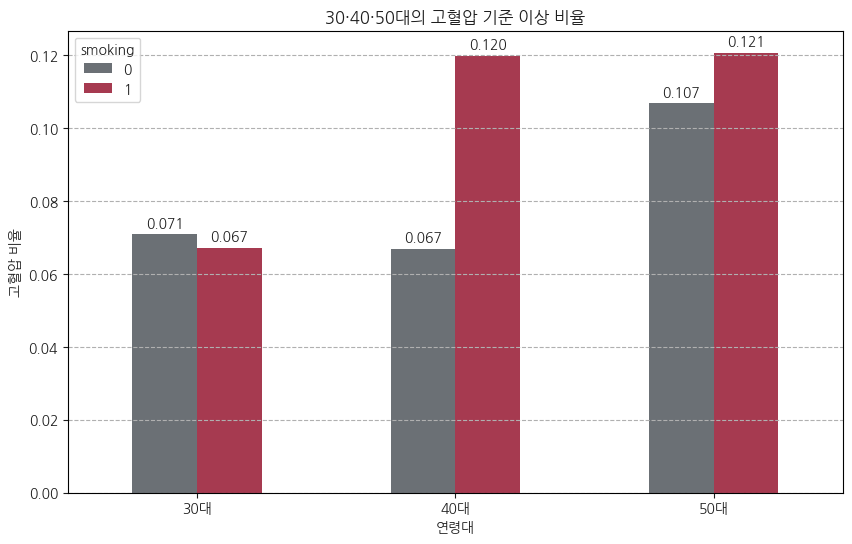

In [ ]:
#추가 분석
#30~50대 고혈압 기준 이상
train['htn'] = (
    (train['systolic'] >= 140) | (train['relaxation'] >= 90)
).astype(int)
htn = train.groupby(['age_group', 'smoking'])['htn'].mean().unstack()
htn_age =htn.loc[['30대', '40대', '50대']]

htn_age.plot(kind="bar", figsize=(10,6), color=[C_NONSMOKER, C_SMOKER])

plt.title('30·40·50대의 고혈압 기준 이상 비율')
plt.xlabel('연령대')
plt.ylabel('고혈압 비율')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)
plt.show()

/tmp/ipykernel_10859/1486472522.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoking_age =train.groupby('age_group')['smoking'].mean()


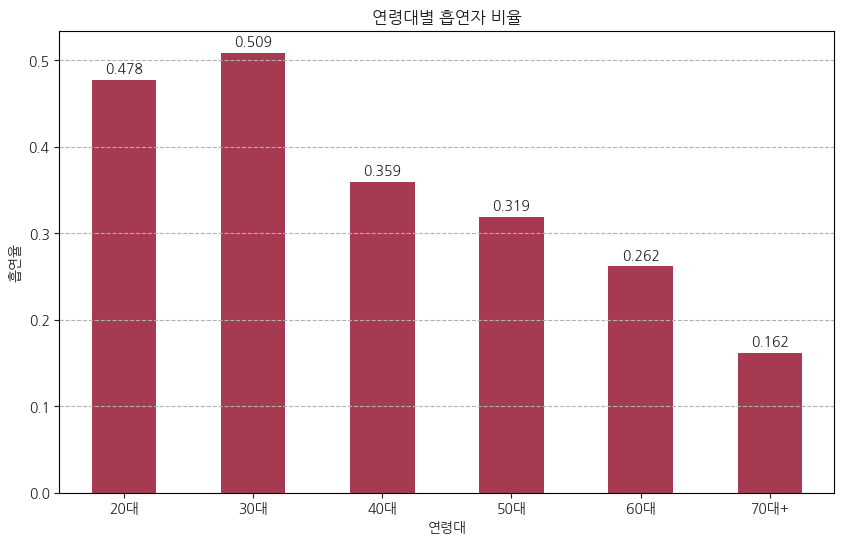

In [ ]:
#연령대별 흡연자 비율
smoking_age =train.groupby('age_group')['smoking'].mean()
smoking_age.plot(kind="bar", figsize=(10,6), color=[C_SMOKER])

plt.title('연령대별 흡연자 비율')
plt.xlabel('연령대')
plt.ylabel('흡연율')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)
plt.show()

/tmp/ipykernel_10859/2990993979.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  htn = train.groupby(['age_group', 'smoking'])['htn'].mean().unstack()


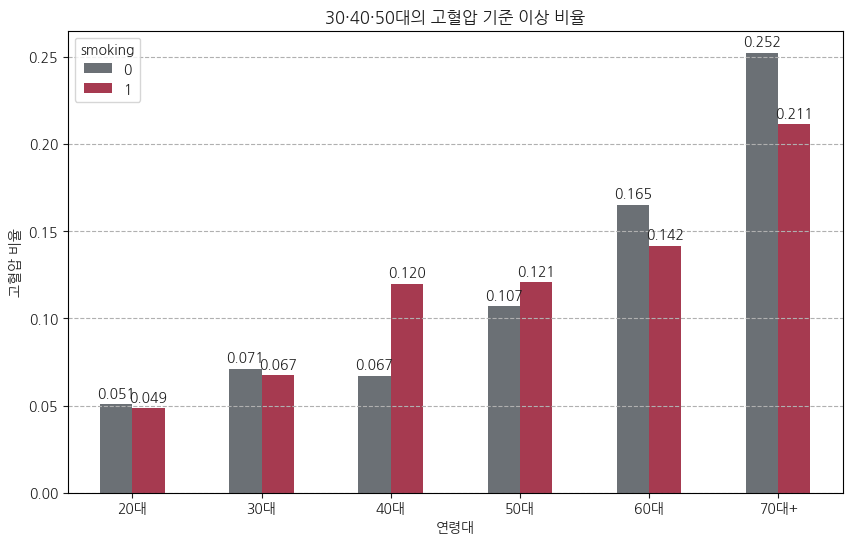

In [ ]:
#연령대별 고혈압 비율 흡연 유무 포함
htn = train.groupby(['age_group', 'smoking'])['htn'].mean().unstack()
htn.plot(kind="bar", figsize=(10,6), color=[C_NONSMOKER, C_SMOKER])

plt.title('30·40·50대의 고혈압 기준 이상 비율')
plt.xlabel('연령대')
plt.ylabel('고혈압 비율')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)
plt.show()

/tmp/ipykernel_10859/76559673.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  htnn = train.groupby('age_group')['htn'].mean()


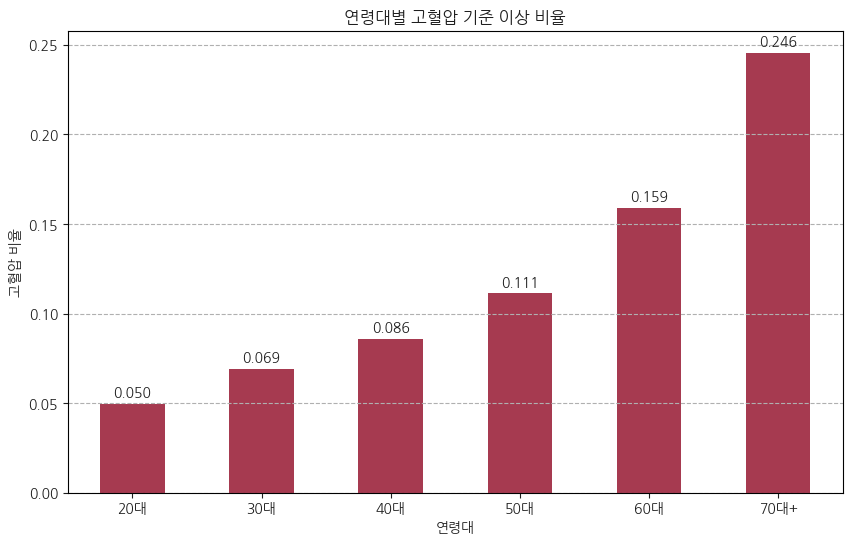

In [ ]:
#연령대별 고혈압 비율 흡연 유무 미포함
htnn = train.groupby('age_group')['htn'].mean()
htnn.plot(kind="bar", figsize=(10,6), color=[C_SMOKER])

plt.title('연령대별 고혈압 기준 이상 비율')
plt.xlabel('연령대')
plt.ylabel('고혈압 비율')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)
plt.show()

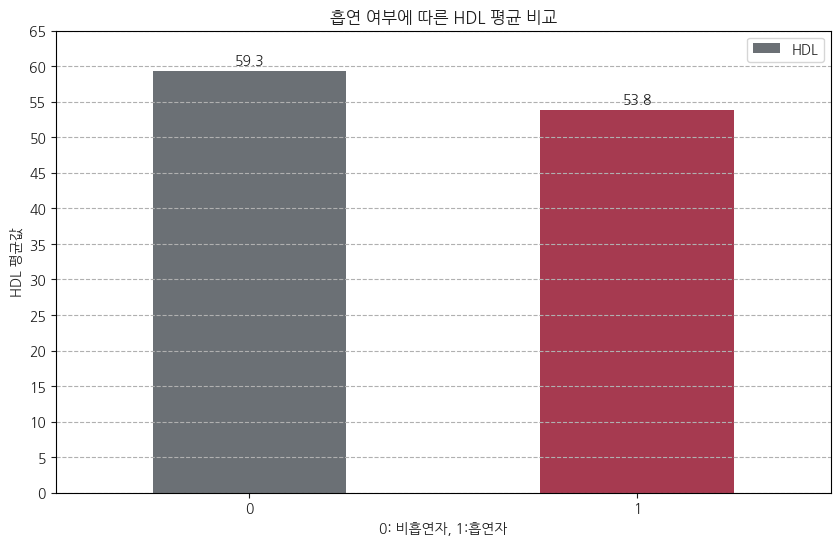

In [ ]:
#흡연king_hd 유무에 따른 HDL 그래프1
smoking_hdl = train.groupby('smoking')['HDL'].mean()
smoking_hdl.plot(kind="bar", figsize=(10,6), color=[C_NONSMOKER, C_SMOKER])

plt.title('흡연 여부에 따른 HDL 평균 비교')
plt.xlabel('0: 비흡연자, 1:흡연자')
plt.ylabel('HDL 평균값')
plt.xticks(rotation=0)
plt.yticks(np.arange(0, smoking_hdl.max() + 10, 5))
plt.legend(['HDL'])
plt.grid(axis='y', linestyle='--')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3)
plt.show()


/tmp/ipykernel_10859/579574508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='smoking', y='HDL', data=train,


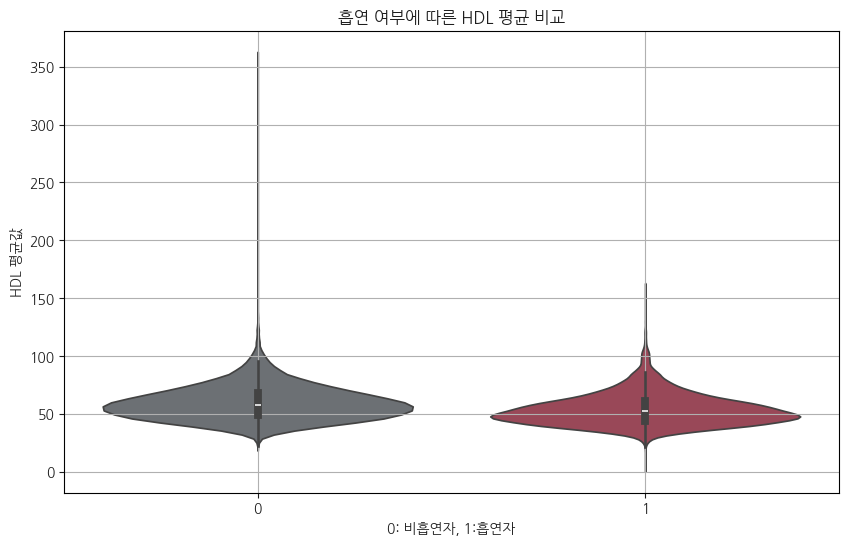

In [ ]:
#흡연 유무에 따른 HDL 그래프2

plt.figure(figsize=(10, 6))
sns.violinplot(x='smoking', y='HDL', data=train,
               palette=[C_NONSMOKER, C_SMOKER])

plt.title('흡연 여부에 따른 HDL 평균 비교')
plt.xlabel('0: 비흡연자, 1:흡연자')
plt.ylabel('HDL 평균값')
plt.grid(True)
plt.show()

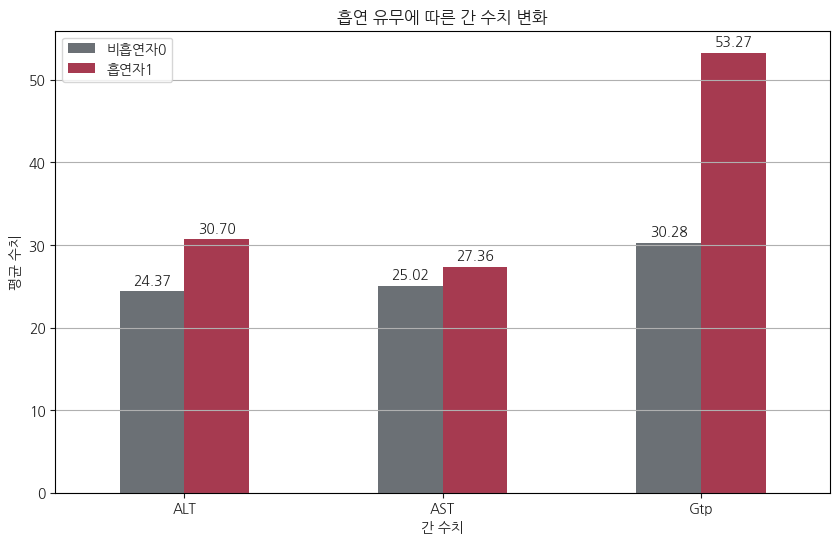

In [ ]:
#가설2 흡연은 간 기능 저하를 유발할 것이다
aag = train.groupby('smoking')[['ALT', 'AST', 'Gtp']].mean()
aag_plot=aag.T
aag_plot.plot(kind="bar", figsize=(10,6),color=[C_NONSMOKER, C_SMOKER])
plt.title('흡연 유무에 따른 간 수치 변화')
plt.xlabel('간 수치')
plt.ylabel('평균 수치')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', padding=3)
plt.show()

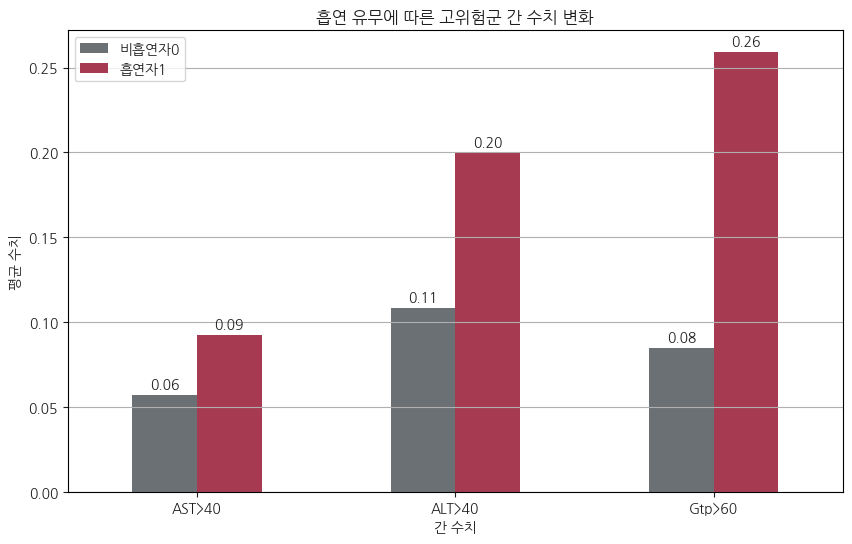

In [ ]:
#고위험군만 따로 분류하기
train['AST>40']= train['AST']> 40
train['ALT>40']= train['ALT']> 40
train['Gtp>60']= train['Gtp']> 60

haag = train.groupby('smoking')[['AST>40', 'ALT>40', 'Gtp>60']].mean()
haag_plot=haag.T
haag_plot.plot(kind="bar", figsize=(10,6),color=[C_NONSMOKER, C_SMOKER])
plt.title('흡연 유무에 따른 고위험군 간 수치 변화')
plt.xlabel('간 수치')
plt.ylabel('평균 수치')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', padding=3)
plt.show()

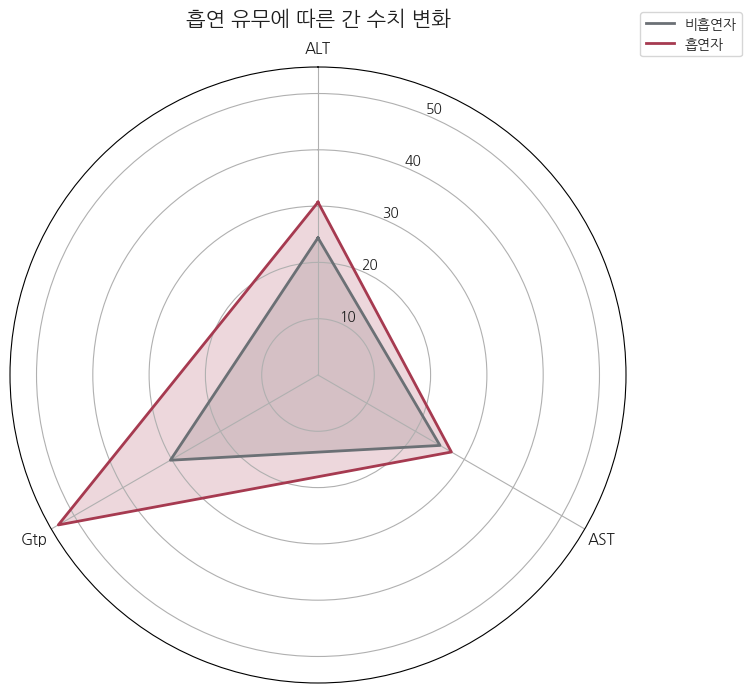

In [ ]:
llen = aag.columns.tolist()
num = len(llen)
angles = [n / float(num) * 2 * pi for n in range(num)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
values_0 = aag.loc[0].tolist()
values_0 += values_0[:1]
ax.plot(angles, values_0, color=C_NONSMOKER, linewidth=2, label='비흡연자')
ax.fill(angles, values_0, color=C_NONSMOKER, alpha=0.2)
values_1 = aag.loc[1].tolist()
values_1 += values_1[:1]
ax.plot(angles, values_1, color=C_SMOKER, linewidth=2, label='흡연자')
ax.fill(angles, values_1, color=C_SMOKER, alpha=0.2)
plt.xticks(angles[:-1], llen, size=11)
plt.title('흡연 유무에 따른 간 수치 변화', pad=30, size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()

/tmp/ipykernel_10859/511881878.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_smoking_gtp = train.groupby(['BMI_group', 'smoking'])['Gtp'].mean().unstack()


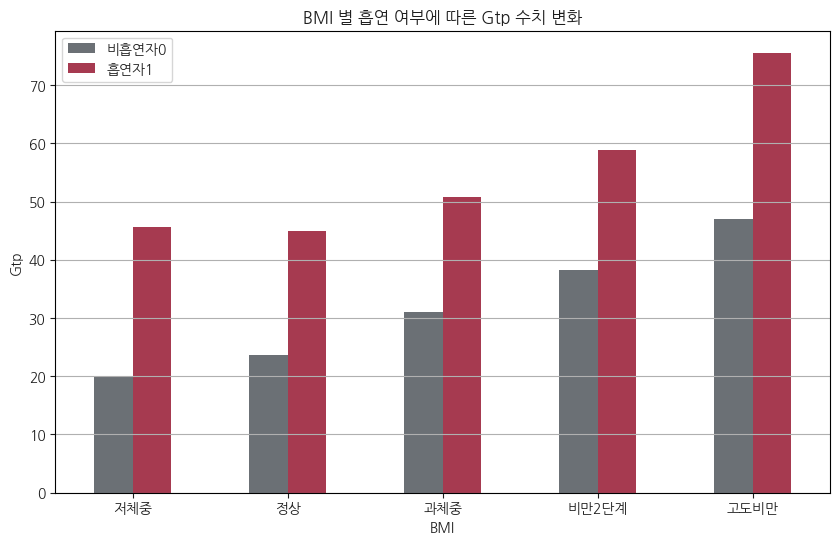

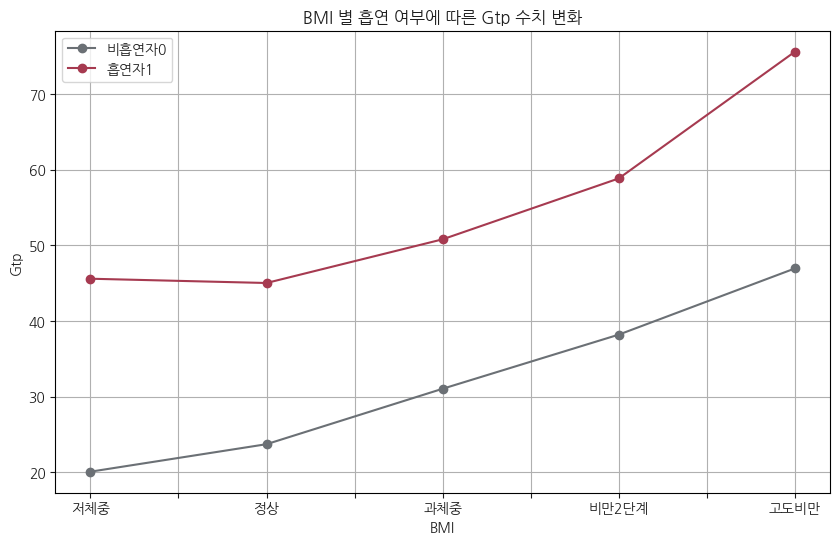

In [ ]:
#가설3 고BMI집단이라는 변수와 흡연이 결합하면 건강에 더 악영향을 줄 것이다
bmi_smoking_gtp = train.groupby(['BMI_group', 'smoking'])['Gtp'].mean().unstack()
bmi_smoking_gtp.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 Gtp 수치 변화')
plt.xlabel('BMI')
plt.ylabel('Gtp')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_gtp.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 Gtp 수치 변화")
plt.xlabel("BMI")
plt.ylabel("Gtp")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

/tmp/ipykernel_10859/1833891370.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_smoking_t = train.groupby(['BMI_group', 'smoking'])['triglyceride'].mean().unstack()


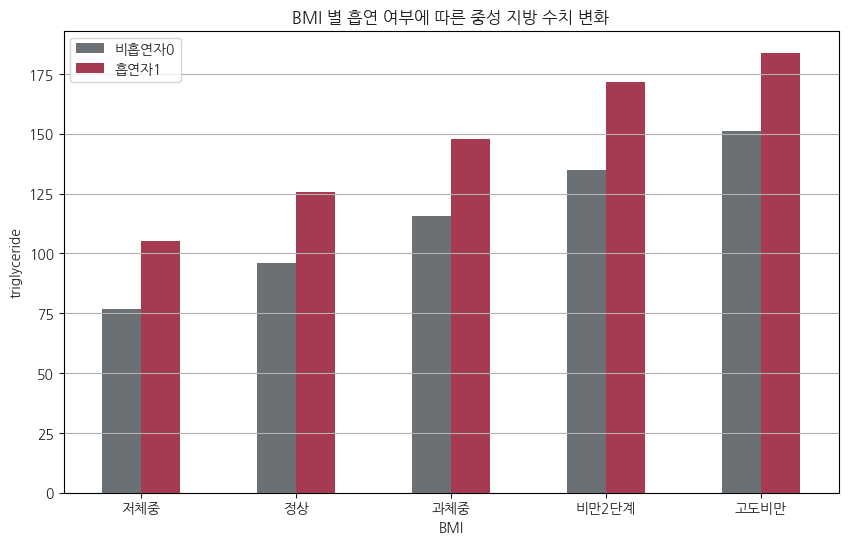

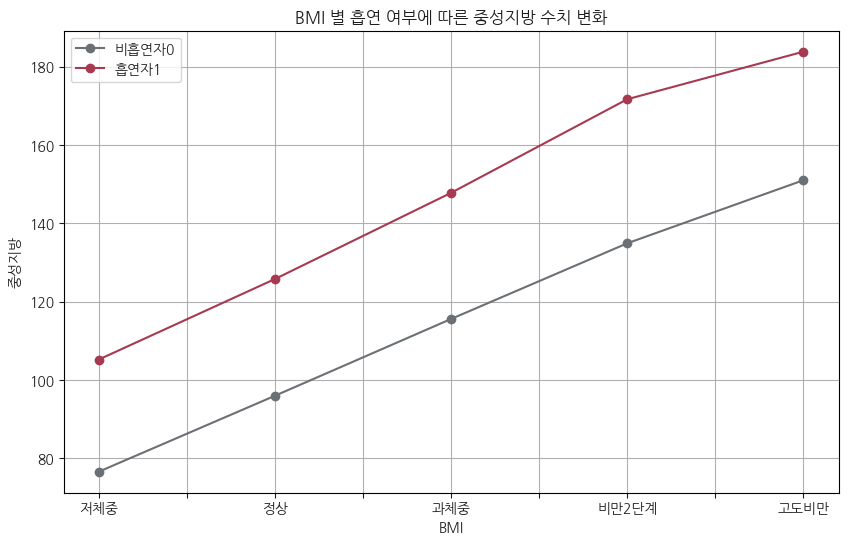

In [ ]:
bmi_smoking_t = train.groupby(['BMI_group', 'smoking'])['triglyceride'].mean().unstack()
bmi_smoking_t.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 중성 지방 수치 변화')
plt.xlabel('BMI')
plt.ylabel('triglyceride')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_t.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 중성지방 수치 변화")
plt.xlabel("BMI")
plt.ylabel("중성지방")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

/tmp/ipykernel_10859/2131239991.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_smoking_ast = train.groupby(['BMI_group', 'smoking'])['AST'].mean().unstack()


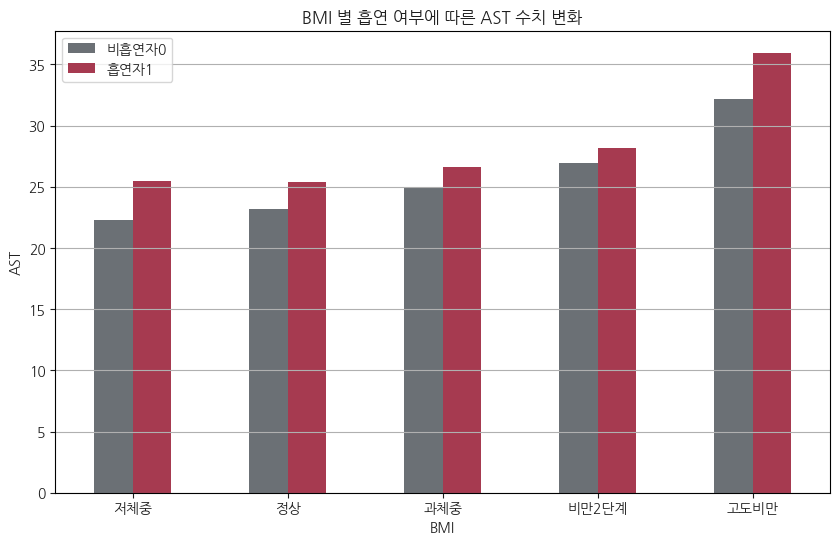

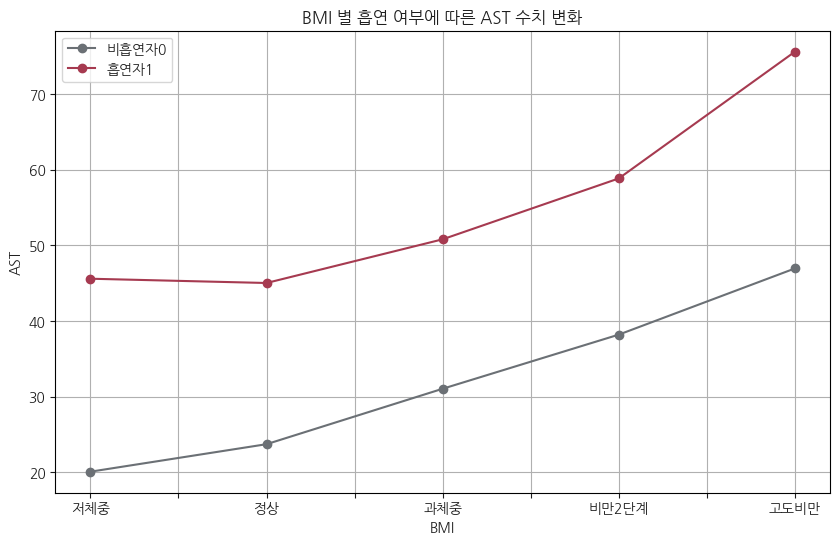

In [ ]:
bmi_smoking_ast = train.groupby(['BMI_group', 'smoking'])['AST'].mean().unstack()
bmi_smoking_ast.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 AST 수치 변화')
plt.xlabel('BMI')
plt.ylabel('AST')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_gtp.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 AST 수치 변화")
plt.xlabel("BMI")
plt.ylabel("AST")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

/tmp/ipykernel_10859/1498879148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_smoking_alt = train.groupby(['BMI_group', 'smoking'])['ALT'].mean().unstack()


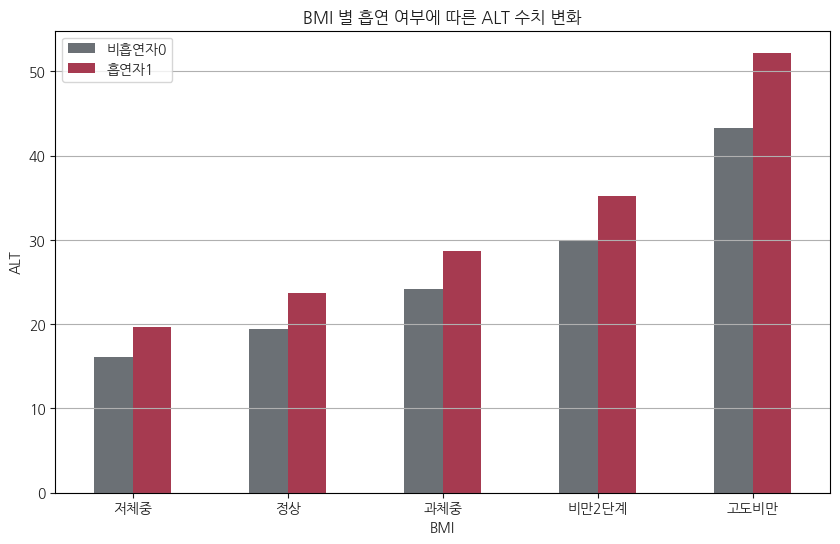

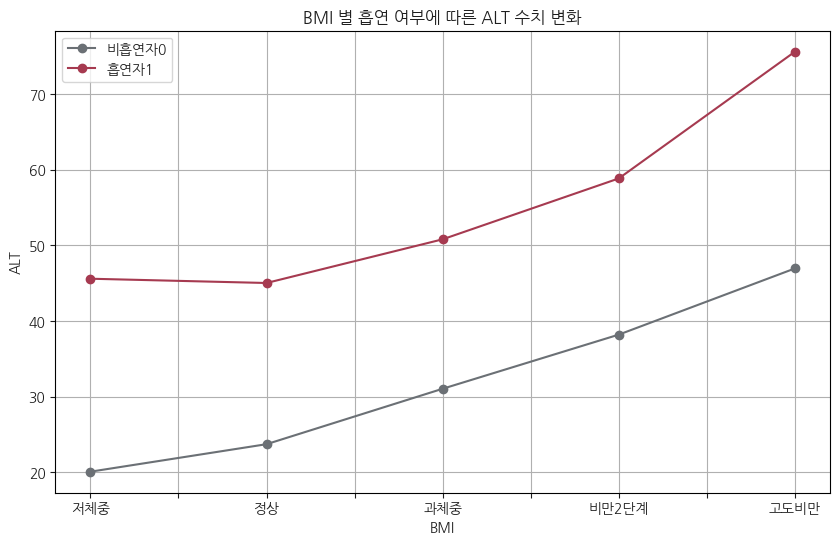

In [ ]:
bmi_smoking_alt = train.groupby(['BMI_group', 'smoking'])['ALT'].mean().unstack()
bmi_smoking_alt.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 ALT 수치 변화')
plt.xlabel('BMI')
plt.ylabel('ALT')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_gtp.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 ALT 수치 변화")
plt.xlabel("BMI")
plt.ylabel("ALT")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

/tmp/ipykernel_10859/916671367.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_smoking_w = train.groupby(['BMI_group', 'smoking'])['waist(cm)'].mean().unstack()


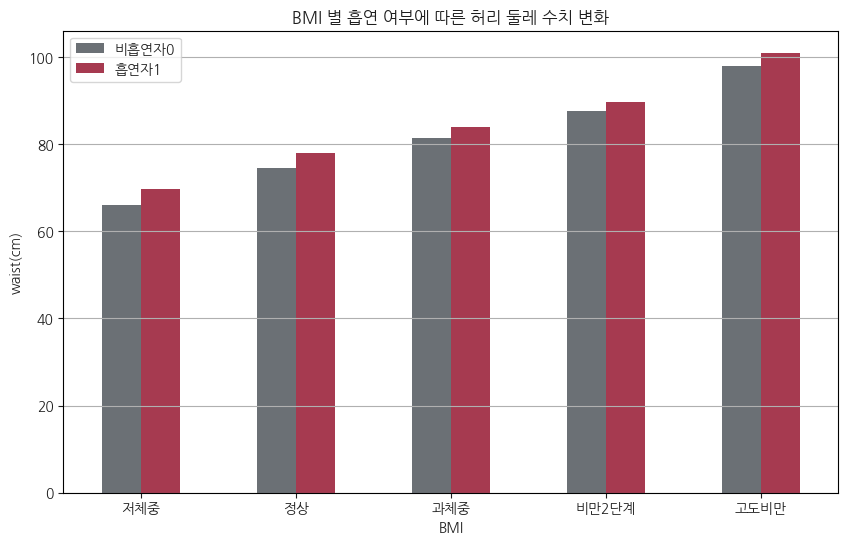

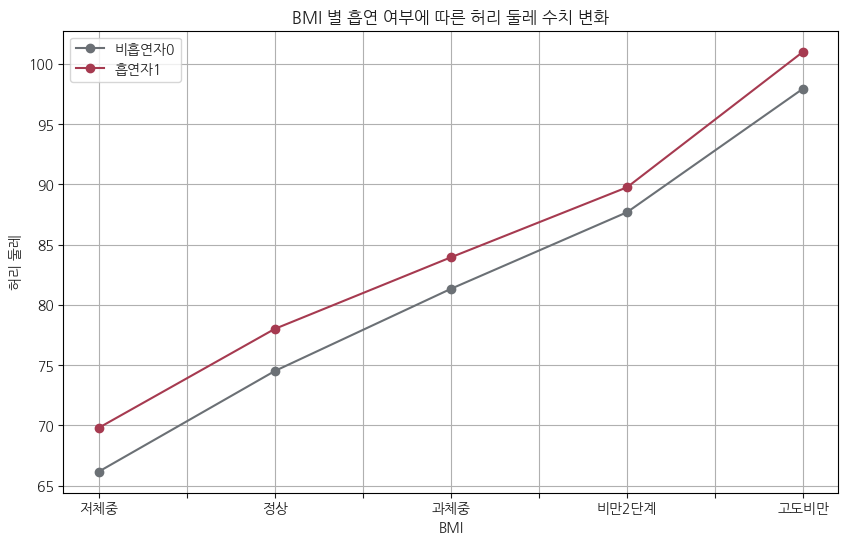

In [ ]:
bmi_smoking_w = train.groupby(['BMI_group', 'smoking'])['waist(cm)'].mean().unstack()
bmi_smoking_w.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 허리 둘레 수치 변화')
plt.xlabel('BMI')
plt.ylabel('waist(cm)')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()


bmi_smoking_w.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 허리 둘레 수치 변화")
plt.xlabel("BMI")
plt.ylabel("허리 둘레")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

/tmp/ipykernel_10859/1781134457.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_smoking_h = train.groupby(['BMI_group', 'smoking'])['HDL'].mean().unstack()


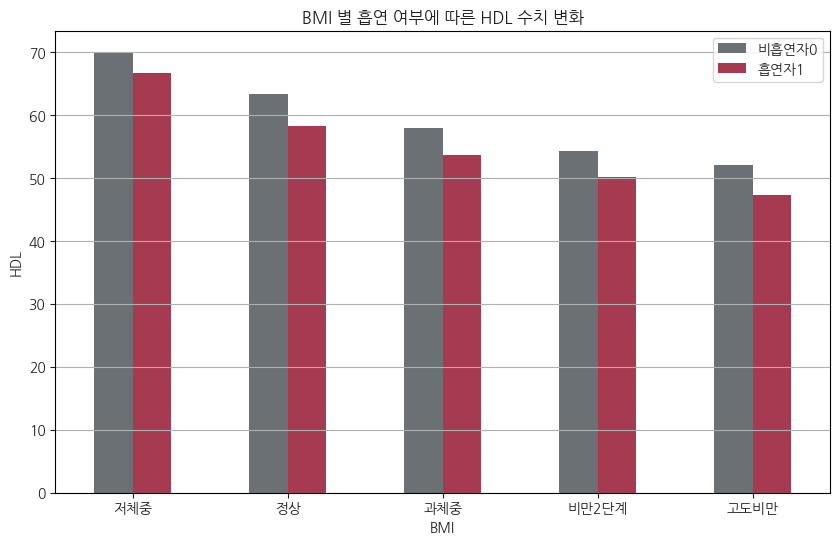

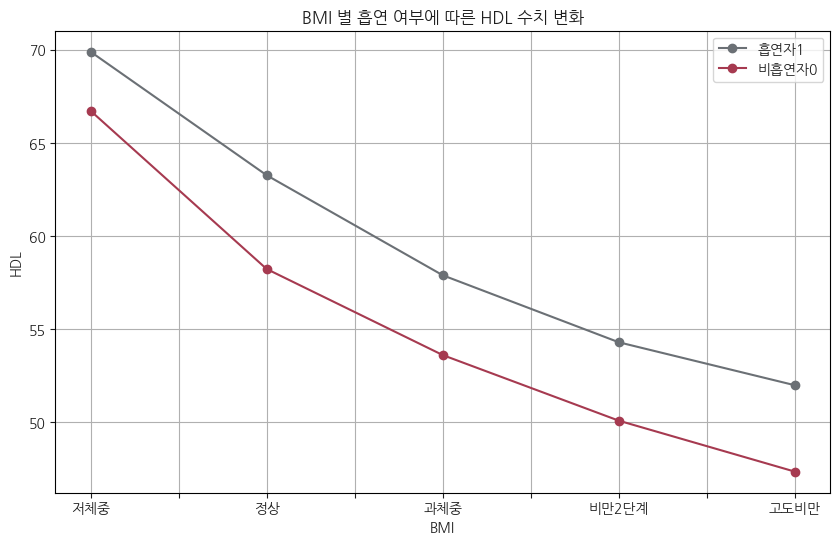

In [ ]:
bmi_smoking_h = train.groupby(['BMI_group', 'smoking'])['HDL'].mean().unstack()
bmi_smoking_h.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 HDL 수치 변화')
plt.xlabel('BMI')
plt.ylabel('HDL')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_h.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 HDL 수치 변화")
plt.xlabel("BMI")
plt.ylabel("HDL")
plt.grid(True)
plt.legend(['흡연자1', '비흡연자0',])
plt.show()

<Figure size 1000x600 with 0 Axes>

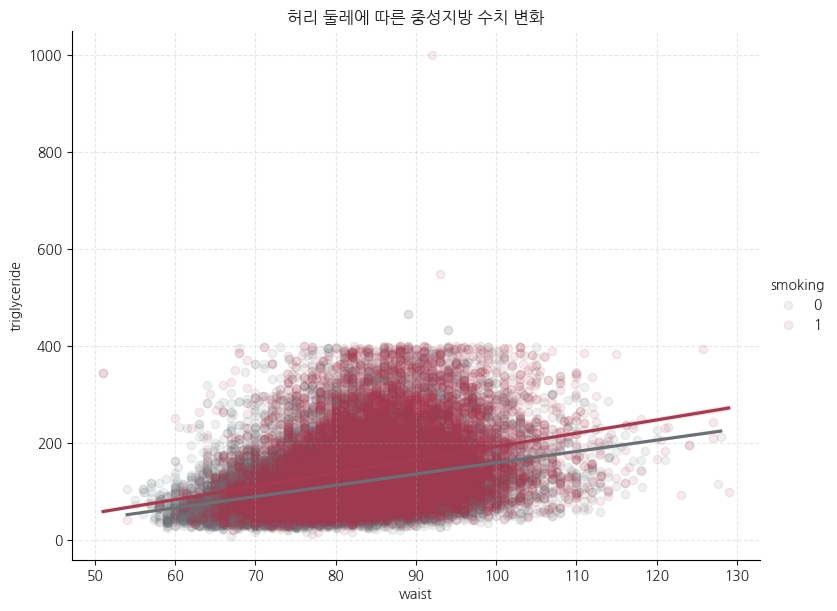

In [ ]:
#허리 둘레, 중성지방 산점도 그려보기
plt.figure(figsize=(10,6))
sns.lmplot(data=train, x='waist(cm)', y='triglyceride',hue='smoking',
           palette={0:C_NONSMOKER,1:C_SMOKER},
           scatter_kws={'alpha':0.1},
           height=6, aspect=1.3)
plt.title("허리 둘레에 따른 중성지방 수치 변화")
plt.xlabel("waist")
plt.ylabel("triglyceride")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

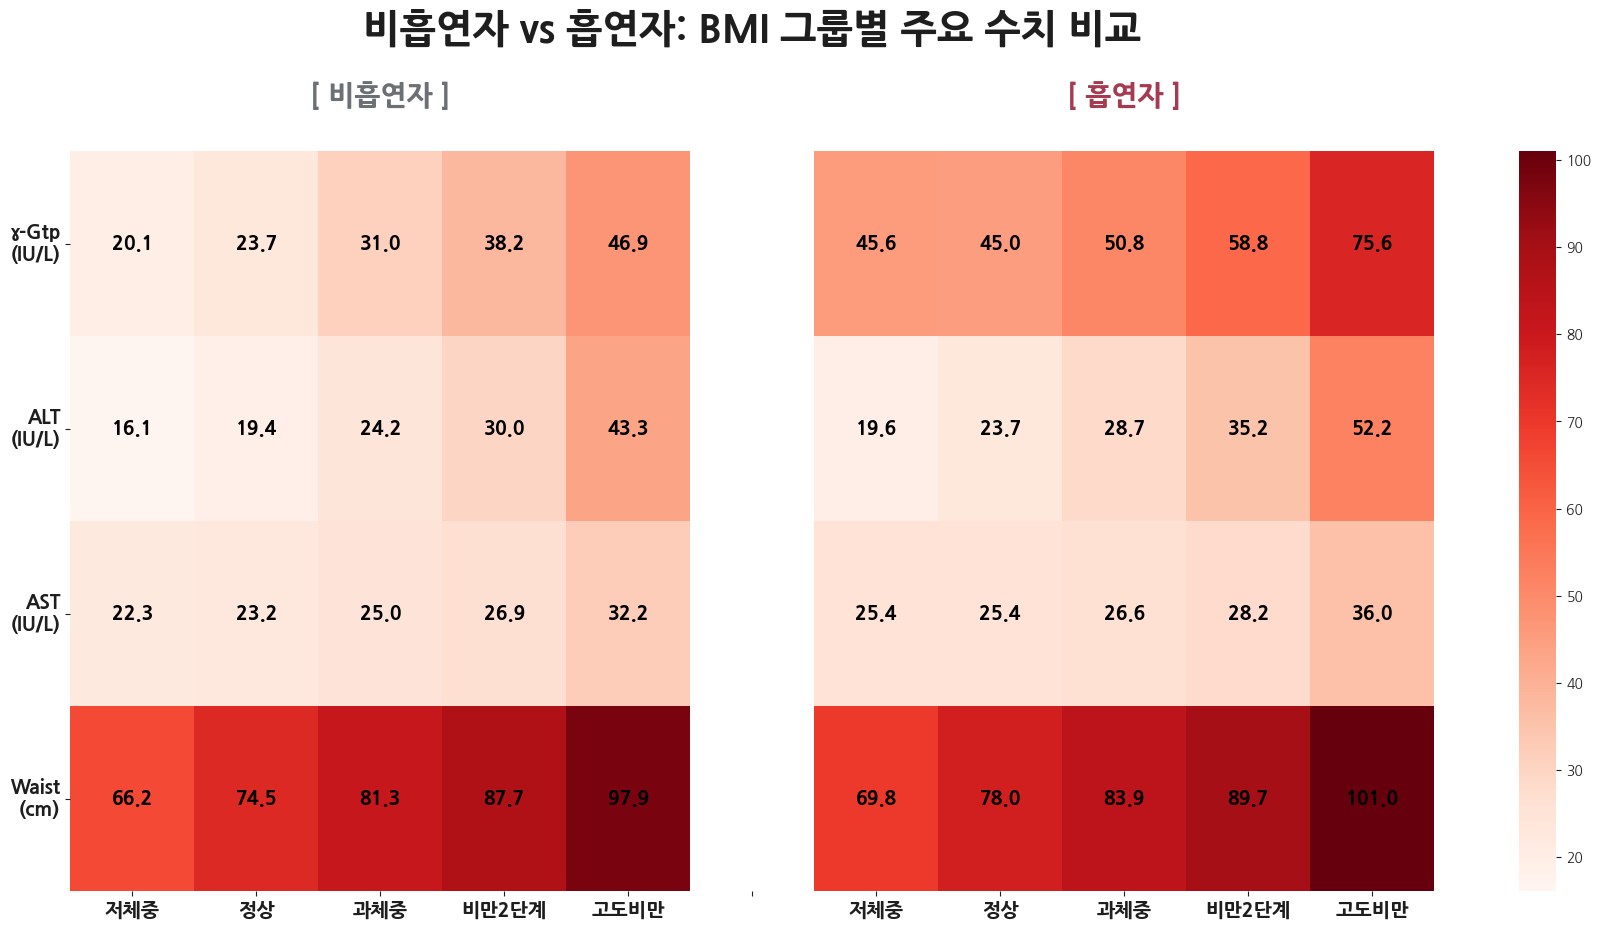

In [ ]:
target_cols = ['Gtp', 'ALT', 'AST', 'waist(cm)']
display_labels = ['γ-Gtp\n(IU/L)', 'ALT\n(IU/L)', 'AST\n(IU/L)', 'Waist\n(cm)']

smoker_no = train[train['smoking'] == 0].groupby('BMI_group', observed=False)[target_cols].mean()
smoker_yes = train[train['smoking'] == 1].groupby('BMI_group', observed=False)[target_cols].mean()

empty_col = pd.DataFrame([[np.nan] * len(target_cols)], index=[' '], columns=target_cols).T
df_combined_t = pd.concat([smoker_no.T, empty_col, smoker_yes.T], axis=1)

x_labels = list(smoker_no.index) + [' '] + list(smoker_yes.index)

fig = plt.figure(figsize=(22, 10), facecolor='none')
ax = sns.heatmap(df_combined_t, annot=True, fmt='.1f', cmap='Reds',
            annot_kws={'size': 14, 'weight': 'bold', 'color':'black'}, cbar_kws={'label': ''})

fig.patch.set_facecolor('none')
ax.set_facecolor('none')

plt.title('비흡연자 vs 흡연자: BMI 그룹별 주요 수치 비교', size=28, fontweight='bold', pad=80)

plt.xticks(np.arange(len(df_combined_t.columns)) + 0.5, x_labels, rotation=0, fontsize=14, fontweight='bold', color =C_TEXT)
plt.yticks(np.arange(len(target_cols)) + 0.5, display_labels, rotation=0, fontsize=14, fontweight='bold', color =C_TEXT)

plt.text(2.5, -0.3, '[ 비흡연자 ]', ha='center', va='center', fontsize=20, fontweight='bold', color=C_NONSMOKER)
plt.text(8.5, -0.3, '[ 흡연자 ]', ha='center', va='center', fontsize=20, fontweight='bold', color=C_SMOKER)

plt.subplots_adjust(top=0.85)
plt.xlabel('', labelpad=15)
plt.ylabel('', labelpad=15)
plt.show()